In [25]:
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [28]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [29]:
df.sort_values(by='Mg25')

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
676,9574,Rel-0,Spain,38.6000,-2.7000,CS77209,leaf,Spain_leaf,3589.943197,13.150001,...,6.669167,12.507027,11.122003,95.303261,1.428568,6.967265,257.971314,46,0.055271,0.050537
675,9515,Ala-0,Spain,39.7200,-6.8900,CS76650,leaf,Spain_leaf,3644.808362,16.612499,...,6.320508,12.135883,8.876810,39.174988,1.491584,10.489875,245.356354,35,0.012738,0.048052
674,9855,Lam-0,Spain,40.5700,-3.8900,CS77008,leaf,Spain_leaf,3700.342494,13.641666,...,6.949802,11.297289,12.935800,68.832222,1.203042,32.050751,234.559372,63,0.048772,0.054213
673,9451,Spro 2,Sweden,57.2545,18.2109,CS77264,leaf,Sweden_leaf,3704.088675,6.970833,...,5.536186,17.553471,22.722700,3.800810,2.715456,27.859510,109.780403,36,0.005225,-0.035328
672,9507,Coa-0,POR,38.4500,-7.5000,CS76775,leaf,POR_leaf,3797.257631,16.049999,...,6.518986,10.030377,10.163026,28.263783,1.410165,14.748399,211.158447,49,0.001880,0.043584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897


In [27]:
df.shape

(677, 47)

In [8]:
no_match=pd.read_table('List_accessions_dont_match_anything.txt',header=None)
no_match.head()

,0
0,6990
1,7164
2,7218
3,7280
4,7332


In [13]:
no_match.shape

(43, 1)

In [18]:
no_match.loc[no_match[0].isin(df['Accession_ID']), 0]

2     7218
3     7280
6     7415
10    8420
11    9592
16    9646
17    9655
18    9657
19    9659
20    9661
21    9691
22    9697
23    9707
24    9709
25    9714
26    9716
27    9723
28    9727
29    9729
30    9735
34    9909
35    9915
36    9917
37    9920
38    9921
39    9924
40    9930
41    9932
42    9937
Name: 0, dtype: int64

In [20]:
no_match.loc[no_match[0].isin(df['Accession_ID']), 0].shape

(29,)

In [19]:
df.loc[df['Accession_ID'] == 9937]

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
162,9937,CATS-6,France,50.79,2.69,CS76760,leaf,France_leaf,5109.927229,9.804167,...,6.958485,9.993786,9.929628,26.639885,2.589607,53.894737,260.111084,37,-0.013351,0.029264


In [21]:
incorrect=pd.read_table('List_accessions_incorrectly_assigned.txt',header=None)
incorrect.head()

,0
0,1819
1,6680
2,7063
3,7125
4,7138


In [24]:
incorrect.shape

(30, 1)

In [22]:
incorrect.loc[incorrect[0].isin(df['Accession_ID']), 0]

1     6680
4     7138
5     7250
6     7307
13    9503
17    9658
20    9790
21    9908
22    9910
23    9911
25    9914
26    9927
27    9928
28    9929
29    9935
Name: 0, dtype: int64

In [23]:
incorrect.loc[incorrect[0].isin(df['Accession_ID']), 0].shape

(15,)

In [4]:
df.shape

(677, 47)

In [3]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [4]:
df=df[df.duplicated(subset=['Country'],keep=False)]

In [5]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

# Random state = 0

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [44]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
102,9.375000,8.366667,33.201057,647.875916,23.500000,-1.7,25.200001,17.483334,4.916667,17.483334,...,5.766342,14.650199,8.348371,21.480152,1.600857,43.021473,184.761032,19,-0.026711,-0.008398
446,3.491667,7.500000,25.951557,764.602783,19.299999,-9.6,28.900000,3.850000,1.833333,13.533334,...,4.477750,24.041798,11.098902,4.859886,3.579735,28.267197,165.351166,37,0.087242,-0.125343
435,3.404167,7.991666,26.462473,798.155396,20.000000,-10.2,30.200001,3.666667,2.050000,13.816667,...,4.284170,25.135468,7.692864,3.940689,1.638144,28.193222,161.718613,36,0.085039,-0.125223
301,12.666667,10.083333,35.380116,663.952820,29.200001,0.7,28.500000,8.800000,21.266666,21.383333,...,6.734649,12.954823,11.492945,45.463810,2.131776,31.524418,244.517151,49,0.050816,0.052446
144,7.900000,6.650000,35.945946,441.495392,18.500000,0.0,18.500000,3.700000,9.400000,13.566667,...,5.437558,12.148521,13.800424,0.000000,3.355493,40.887100,242.019302,38,-0.036145,0.016419


In [45]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
553,7.087500,7.058333,37.948029,435.253967,17.799999,-0.8,18.599998,2.916667,8.533333,12.683333,...,5.527695,10.952459,11.628180,0.000000,3.017148,35.610485,243.167252,45,-0.017136,0.026012
505,12.029166,9.474999,38.991772,552.870422,25.799999,1.5,24.299999,8.866667,18.983334,18.983334,...,6.258976,14.338577,14.163638,45.276859,2.179187,6.705092,194.824951,31,-0.019014,0.018923
465,11.150001,9.800000,32.775921,762.081482,27.000000,-2.9,29.900000,20.516666,1.800000,20.516666,...,6.747277,12.311311,26.320547,37.449226,2.948513,26.362236,165.593308,52,-0.014154,-0.022436
336,9.225000,9.550000,32.931038,735.166931,24.799999,-4.2,29.000000,12.966667,14.683333,18.133333,...,6.659183,14.500295,22.828438,44.163082,2.267880,16.759745,215.018997,41,-0.007146,0.001085
14,7.395833,8.241667,30.079075,733.808411,22.500000,-4.9,27.400000,16.350000,-0.300000,16.350000,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.050138,-0.004487


In [46]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 3, 'max_leaf_nodes': 5, 'n_estimators': 200}
0.16823769682624662


In [47]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 289.27
Mean Squared Error: 138621.27
R-squared scores: 0.21


In [48]:
from sklearn.inspection import permutation_importance

result = permutation_importance(forest_model_cv, X_test, y_test, n_repeats=100, n_jobs=4)
model_importances = pd.Series(result.importances_mean, index=X_train.columns)

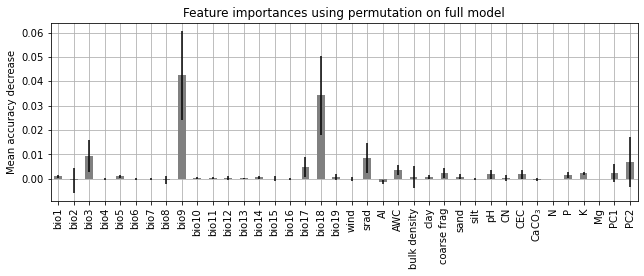

In [49]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c_20240912.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# Random state = 1

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [58]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
188,8.479167,7.008333,38.088768,424.100433,19.000000,0.6,18.4,8.883333,5.200000,14.016666,...,5.309776,15.969325,18.667496,74.473305,2.908743,29.603725,166.007599,41,-0.001539,-0.004080
317,7.783333,6.833333,28.954802,643.835571,21.100000,-2.5,23.6,4.650000,2.666667,15.966667,...,5.988177,14.969644,9.420408,6.893508,1.767194,34.157993,112.461731,37,0.001714,-0.058532
162,9.804167,7.091667,33.769840,512.992371,21.600000,0.6,21.0,10.683333,5.883333,16.116667,...,6.958485,9.993786,9.929628,26.639885,2.589607,53.894737,260.111084,37,-0.013351,0.029264
616,10.008333,9.683333,33.506344,724.364441,25.600000,-3.3,28.9,6.233333,18.416666,18.916668,...,5.348785,14.462580,16.551249,2.945889,1.524456,4.798762,206.728210,34,-0.010535,0.015107
326,13.120833,8.625000,43.125000,423.794861,23.799999,3.8,20.0,11.083333,18.383333,18.650000,...,6.706738,12.072179,18.370918,138.761948,2.736146,10.215800,211.943863,40,0.000881,0.018317


In [59]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
407,15.412500,9.691667,39.719944,552.136841,28.600000,4.2,24.400002,10.216667,22.299999,22.299999,...,7.336013,10.289663,17.509703,60.877995,2.114833,32.692707,427.364594,43,-0.022562,0.022006
615,16.529167,7.825000,32.468880,607.986450,30.200001,6.1,24.100000,13.883333,24.200001,24.233334,...,7.598414,9.936677,14.772600,101.750450,1.480609,11.967968,205.761917,51,-0.024748,0.024046
378,12.929167,11.225000,35.748409,716.048035,31.299999,-0.1,31.400000,8.650000,22.233334,22.416666,...,6.589819,11.735341,10.378104,43.847084,1.333466,6.608674,215.566559,33,0.121344,0.053729
499,8.650000,7.033333,36.631943,454.077484,19.600000,0.4,19.200001,4.416667,12.866667,14.466666,...,5.686490,12.865416,9.941420,21.108318,3.329602,34.973095,151.055954,49,0.028227,-0.020909
58,10.066667,6.683333,32.131409,523.025879,21.500000,0.7,20.799999,10.950000,8.933333,16.516666,...,6.460595,14.590979,10.351868,60.002895,1.773701,26.090187,125.968071,42,0.012272,-0.016238


In [60]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 5, 'n_estimators': 200}
0.16290309394842817


In [61]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 298.02
Mean Squared Error: 140837.5
R-squared scores: 0.23


In [65]:
from sklearn.inspection import permutation_importance

result = permutation_importance(forest_model_cv, X_test, y_test, n_repeats=1000, n_jobs=4)
model_importances = pd.Series(result.importances_mean, index=X_train.columns)

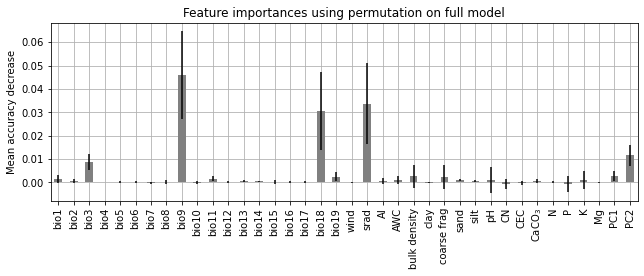

In [64]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
plt.savefig("Fig1c_20240919.pdf", format="pdf",bbox_inches="tight",facecolor="w")

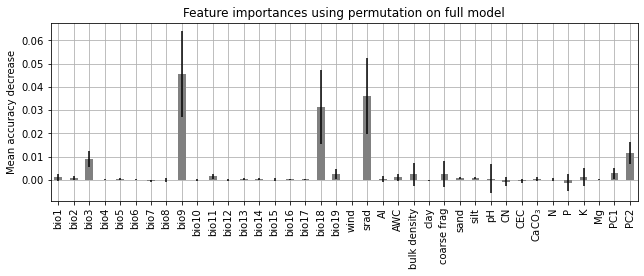

In [66]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
plt.savefig("Fig1c_20240919.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [2]:
df2=pd.read_table('Fig1c_test.txt')
df2.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,Mg,PC1,PC2,S470fs,top_peak,splice,N715A,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,38,-0.024919,0.024124,0,0,0,1,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,31,-0.017065,0.018734,0,0,0,1,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,31,-0.018403,0.018840,0,0,0,1,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,29,-0.029610,0.022555,0,0,0,1,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,36,-0.029266,0.026182,0,0,0,1,0.0,0.0,1.0


In [4]:
df2=df2.dropna()

In [5]:
df2=df2[df2.duplicated(subset=['Country'],keep=False)]

In [6]:
X=df2.drop(columns=['Mg25'])
y=df2['Mg25']

In [52]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0,stratify=X['Country'])

In [53]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
619,10.158334,7.583333,34.159161,547.119873,22.9,0.7,22.199999,7.133333,6.216667,16.983334,...,1.362831,1.860576,46.690781,205.509262,37,-0.008169,0.015554,0.0,0.0,1.0
283,10.079166,8.125000,31.988190,661.422241,24.4,-1.0,25.400000,16.783333,3.250000,18.383333,...,38.131313,1.570979,23.699923,141.818512,42,-0.037216,-0.001287,0.0,0.0,1.0
473,12.004167,10.725000,33.939873,775.430847,29.0,-2.6,31.600000,7.700000,20.950001,21.549999,...,72.673447,1.338050,19.887054,249.277084,40,0.002278,0.011588,0.0,0.0,1.0
98,7.820833,6.758333,28.758865,642.680664,21.0,-2.5,23.500000,4.750000,2.666667,15.966666,...,2.897898,2.495770,38.483131,89.823921,36,-0.019560,-0.040287,0.0,0.0,1.0
461,11.250000,9.366667,31.537598,767.673584,27.0,-2.7,29.700001,16.600000,1.733333,20.616667,...,105.279900,1.976948,30.124363,168.221390,52,-0.020131,-0.015884,0.0,0.0,1.0


In [54]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
270,9.950000,7.700000,37.745098,475.461517,21.600000,1.2,20.400000,5.466667,14.300000,16.000000,...,17.212914,3.450265,39.596661,211.670746,34,-0.028628,0.002165,0.0,0.0,0.0
407,12.708333,8.316667,41.792294,433.583557,23.100000,3.2,19.900000,10.566667,18.083334,18.283333,...,0.000000,2.819362,37.183872,268.577087,41,0.009936,0.011404,1.0,0.0,1.0
513,8.375000,9.400000,35.074627,659.853638,23.500000,-3.3,26.799999,14.916667,1.516667,16.633333,...,0.000000,2.160906,40.403454,220.521973,46,-0.034134,0.009626,0.0,0.0,1.0
545,11.633333,11.900000,40.202702,632.427978,29.000000,-0.6,29.600000,7.883333,19.633333,19.816666,...,35.766224,0.961916,13.741580,154.928467,55,0.035880,0.049226,0.0,0.0,1.0
294,8.904166,7.875000,31.882591,643.906616,22.799999,-1.9,24.699999,15.466666,4.733333,17.000000,...,4.578620,1.903177,48.942635,256.557770,47,-0.032175,-0.006864,0.0,0.0,1.0


In [55]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.27481514103990345


In [56]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 259.88
Mean Squared Error: 111568.13
R-squared scores: 0.34


In [57]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

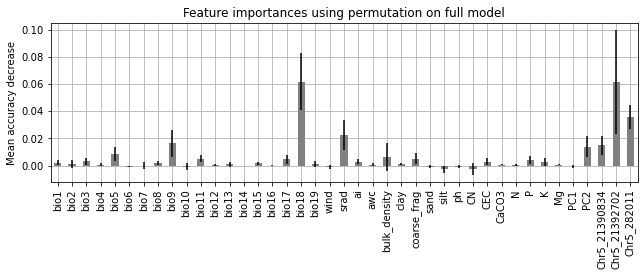

In [58]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [67]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
56,7.395833,8.241667,30.079075,733.808411,22.5,-4.9,27.400000,16.350000,-0.300000,16.350000,...,0.000000,2.134119,38.884171,205.518021,47,-0.048415,-0.004799,0.0,0.0,1.0
107,7.391667,7.000000,29.166666,640.670227,21.0,-3.0,24.000000,4.250000,6.116667,15.566667,...,5.642708,1.997355,45.221046,102.324402,36,0.001657,-0.054085,0.0,0.0,1.0
550,14.287500,11.358334,37.240437,687.773498,31.9,1.4,30.500000,10.166667,23.133333,23.316668,...,98.123154,1.281459,4.819803,389.506867,63,0.046898,0.052252,0.0,0.0,0.0
396,9.904167,9.941667,37.801014,585.108582,25.0,-1.3,26.299999,4.100000,17.450001,17.450001,...,0.000000,1.978678,19.038818,136.133865,22,0.000624,0.029434,0.0,0.0,1.0
339,14.812500,13.341666,39.355949,726.182800,34.5,0.6,33.900002,10.350000,24.083334,24.300001,...,185.951920,1.419635,12.807637,246.669678,57,0.045033,0.050441,0.0,0.0,1.0


In [68]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude','S470fs','top_peak','splice','N715A'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
304,5.337500,7.625000,28.773584,695.286499,20.400000,-6.1,26.5,13.116667,-0.033333,14.266666,...,0.000000,3.240004,16.466581,118.408272,26,-0.004129,-0.036453,0.0,0.0,1.0
92,8.116667,6.616667,28.276354,643.097351,21.299999,-2.1,23.4,8.850000,2.966667,16.233334,...,0.000000,1.684821,47.232983,134.288239,35,-0.015570,-0.032581,0.0,0.0,1.0
301,3.629167,7.491666,25.922722,762.541992,19.400000,-9.5,28.9,4.016666,1.950000,13.650000,...,4.951549,2.901053,30.837130,168.004746,37,0.096012,-0.133015,0.0,0.0,1.0
429,15.025001,9.583333,36.858974,612.441101,29.200001,3.2,26.0,12.133333,22.716667,22.716667,...,128.650070,1.927920,36.183582,625.426209,45,-0.024129,0.021362,0.0,0.0,0.0
564,14.029166,11.325001,37.624584,676.499878,31.400000,1.3,30.1,9.983334,22.733334,22.883333,...,24.095167,1.310741,18.553848,208.961883,63,0.038299,0.050891,0.0,0.0,1.0


In [69]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 42)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.31553192124193985


In [70]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 291.61
Mean Squared Error: 126728.35
R-squared scores: 0.22


In [71]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

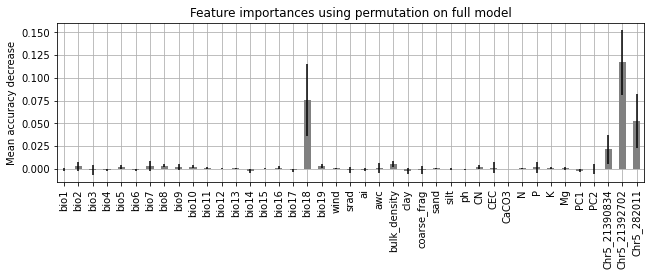

In [72]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")